In [23]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

from keras_yamnet import params
from keras_yamnet.yamnet import YAMNet
from keras_yamnet.preprocessing import preprocess_input
from keras_yamnet.postprocessing import postprocess_output
import tensorflow as tf

import soundfile as sf
import os
import platform
import time
from tqdm import tqdm
import pickle
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
import h5py
from sklearn.utils import shuffle
from sed_eval.sound_event import EventBasedMetrics, SegmentBasedMetrics
from dataset import conversion_functions as cf
import settings
import importlib
importlib.reload(settings)

print("CUDA available:", torch.cuda.is_available())  # should be True
print("Wheel CUDA runtime:", torch.version.cuda)     # should be '11.8'
print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
Wheel CUDA runtime: 11.8
GPU: NVIDIA GeForce RTX 3070 Laptop GPU


In [30]:
# Functions and Classes

class ModifiedModel(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 512)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(512, num_classes)
        # self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        # x = self.sigmoid(x)
        return x
    
def save_arrays_to_cache(x, y, cache_file):
    with h5py.File(cache_file, 'w') as f:
        dset_x = f.create_dataset('x', shape=x.shape, dtype=x.dtype)
        dset_y = f.create_dataset('y', shape=y.shape, dtype=y.dtype)
        for i in tqdm(range(x.shape[0]), desc='Saving x to cache'):
            dset_x[i] = x[i]
        for i in tqdm(range(y.shape[0]), desc='Saving y to cache'):
            dset_y[i] = y[i]

def load_arrays_from_cache(cache_file):
    with h5py.File(cache_file, 'r') as f:
        x = f['x'][:]
        y = f['y'][:]
    return x, y

def load_features_and_labels_from_cache(gt_path, audios_folders, base_model, force_reload):

    cache_file = os.path.splitext(gt_path)[0] + '.npz'

    if os.path.exists(cache_file) and not force_reload:
        print(f"Loading cached result from {cache_file} ...")
        x, y = load_arrays_from_cache(cache_file)
    else:
        print(f'Processing and caching in : {cache_file}')
        x, y = load_features_and_array_labels(gt_path, audios_folders, base_model)
        save_arrays_to_cache(x, y, cache_file)

    return x, y


def load_features_and_array_labels(gt_path, audio_folders, base_model):
    """
    Load training data from ground truth file and preprocess it.

    Args:
        gt_file (pd.DataFrame): DataFrame containing ground truth data.
    Returns:
        input_array (np.ndarray): Array of preprocessed audio data patches.
        output_array (np.ndarray): Array of target outputs corresponding to the audio data. 
            Contains targets that are one-hot encoded vectors for each class.
    """
    gt_file = pd.read_csv(gt_path, sep='\s+')

    audiofile_to_detection = {}  
    audiofile_to_patches = {}  
    class_to_count = [0 for _ in range(settings.N_CLASSES)]
    n_detections = 0

    for _, row in tqdm(gt_file.iterrows(), total=len(gt_file), desc='Loading gt'):
        audiofile = row['filename']

        starttime = row['start_time']
        endtime = row['end_time']
        class_idx = row['class']

        patch_index_start = cf.second_to_index(starttime)
        patch_index_end = cf.second_to_index(endtime)

        class_to_count[class_idx] += 1

        n_detections += 1

        if audiofile not in audiofile_to_detection:
            audio_path = None
            for audio_folder in audio_folders:
                candidate = os.path.join(audio_folder, audiofile)
                if os.path.exists(candidate):
                    audio_path = candidate
                    break

            if audio_path is None:
                raise FileNotFoundError(f'Audio file {audiofile} not found in any of the specified folders.')

            audio_wave, sample_rate = sf.read(audio_path)
            data_patches, _ = preprocess_input(audio_wave, sample_rate)
            audiofile_to_patches[audiofile] = data_patches

            pred = np.zeros((len(data_patches), settings.N_CLASSES), dtype=np.float32)
            pred[patch_index_start:patch_index_end+1, class_idx] = settings.GT_CONFIDENCE
            audiofile_to_detection[audiofile] = pred

        else:
            audiofile_to_detection[audiofile][patch_index_start:patch_index_end, class_idx] = settings.GT_CONFIDENCE

    print(f'Number of instances of class Aircraft: {class_to_count[1]} \n Number of instances of class No aircraft: {class_to_count[0]} \n Total number of instances: {n_detections}')
    
    input_array = []
    output_array = []

    for audiofile in audiofile_to_detection: 
        data_patches = audiofile_to_patches[audiofile]
        pred = audiofile_to_detection[audiofile]

        input_array.append(data_patches)
        output_array.append(pred)
        
    input_array = np.concatenate(input_array, axis=0)  # shape: (num_patches, PATCH_FRAMES, n_bands)
    output_array = np.concatenate(output_array, axis=0)  # shape: (num_patches, N_CLASSES)
    print(f"output_array shape: {np.array(output_array).shape}")

    input_embedding = base_model.predict(input_array, verbose=1)
    print(f"input_embedding shape: {np.array(input_embedding).shape}")
    
    return input_embedding, output_array

def visualize_and_save_history(history, timestamp):
    """
    Visualize training history.
    
    Args:
        history (tf.keras.callbacks.History): History object containing training metrics.
    """

    fig, axs = plt.subplots(2, 1, figsize=(12, 10))

    # Loss subplot
    axs[0].plot(history.history['loss'], label='Training Loss', color='#003366')  # Dark blue
    axs[0].plot(history.history['val_loss'], label='Validation Loss', color='#66b3ff')  # Light blue
    axs[0].set_title('Training and Validation Loss')
    axs[0].set_xlabel('Epochs')
    axs[0].set_ylabel('Loss')
    axs[0].set_ylim(0, 1.5)
    axs[0].legend()
    axs[0].grid()

    # F1-SCORE  subplot
    axs[1].plot(history.history['f1_score'], label='Training f1-score', color='#006400')  # Dark green
    axs[1].plot(history.history['val_f1_score'], label='Validation f1-score', color='#90ee90')  # Light green
    axs[1].set_title('Training and Validation f1-score')
    axs[1].set_xlabel('Epochs')
    axs[1].set_ylabel('f1-score')
    axs[1].set_ylim(0, 1)
    axs[1].legend()
    axs[1].grid()

    plt.tight_layout()
    plt.show()

    os.makedirs('history', exist_ok=True)
    os.makedirs(f'history/{timestamp}', exist_ok=True)
    fig.savefig(f'history/{timestamp}/history.png')

def predictions_to_event_list(predictions):
    """
    Convert model predictions to a list of detected events compatible with sed_eval.
    Assumes predictions are binary (0 or 1) for each class at each segment.
    """
    output = []
    predictions = np.array(predictions)
    num_segments, num_classes = predictions.shape

    for i in range(num_segments):
        for class_idx, score in enumerate(predictions[i]):
            if score == 1:
                output.append({
                    'file': 'an_audio',
                    'event_label': settings.CLASS_NAMES[class_idx],
                    'onset': i * params.PATCH_WINDOW_SECONDS,
                    'offset': (i + 1) * params.PATCH_WINDOW_SECONDS
                })

    return output

def print_metrics(metrics, title):
    print(f"\n{title}")
    overall = metrics['overall']
    print(f"  F1: {overall['f_measure']['f_measure']:.3f} | Precision: {overall['f_measure']['precision']:.3f} | Recall: {overall['f_measure']['recall']:.3f}")
    print(f"  Error Rate: {overall['error_rate']['error_rate']:.3f}")
    if 'accuracy' in overall and overall['accuracy']:
        acc = overall['accuracy'].get('accuracy', None)
        if acc is not None:
            print(f"  Accuracy: {acc:.3f}")
    print("  Class-wise F1:")
    for cls, vals in metrics['class_wise'].items():
        f1 = vals['f_measure']['f_measure']
        print(f"    {cls}: {f1:.3f}")

def get_data_from_dict(data_dict, base_model, force_reload= settings.FORCE_RELOAD_TRAIN):
    X = None
    y = None

    for gt_path, audios_folders in data_dict.items():

        X_temp, y_temp = load_features_and_labels_from_cache(gt_path, audios_folders, base_model, force_reload)

        if X is None and y is None:
            X = X_temp
            y = y_temp
        else:
            X = np.concatenate((X, X_temp), axis=0)
            y = np.concatenate((y, y_temp), axis=0)

    X, y = shuffle(X, y, random_state=42)

    return X, y

def get_device():
    # 1) NVIDIA GPU (Windows/Linux/macOS w/ eGPU): fastest if available
    if torch.cuda.is_available():
        return torch.device("cuda"), "cuda"

    # 2) Apple Silicon GPU (macOS M1/M2/M3)
    if platform.system() == "Darwin" and torch.backends.mps.is_available():
        # Optional: allow silent CPU fallback for unsupported ops on MPS
        os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")
        return torch.device("mps"), "mps"

    # 3) DirectML (Windows + AMD/Intel/NVIDIA via the 'torch-directml' package)
    #    pip install torch-directml   (import torch_directml)  -> a separate package
    try:
        if platform.system() == "Windows":
            import torch_directml  # noqa: F401
            dml = torch_directml.device()
            return dml, "directml"
    except Exception:
        pass

    # 4) CPU fallback (works everywhere)
    return torch.device("cpu"), "cpu"

def save_sed_metric(filename, metric, timestr):
    with open(f'history/{timestr}/{filename}.pk1', "wb") as f:
        pickle.dump(metric, f)

def load_sed_metric(filepath):
    with open(filepath, "rb") as f:
        metric = pickle.load(f)
    return metric

def train_model(X_embedding, y_embedding, model, device, title=None, save=True):
    
    # Prepare PyTorch datasets and loaders
    X_tensor = torch.tensor(X_embedding, dtype=torch.float32).to(device)
    y_tensor = torch.tensor(y_embedding, dtype=torch.float32).to(device)
    print("y_tensor shape:", y_tensor.shape)
    dataset = torch.utils.data.TensorDataset(X_tensor, y_tensor)
    train_loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

    # Validation split
    val_split = getattr(settings, "VAL_SIZE", 0.2)
    num_val = int(len(X_tensor) * val_split)
    indices = np.arange(len(X_tensor.cpu()))
    np.random.shuffle(indices)
    val_indices = indices[:num_val]
    train_indices = indices[num_val:]
    X_val_tensor = X_tensor[val_indices]
    y_val_tensor = y_tensor[val_indices]
    val_dataset = torch.utils.data.TensorDataset(X_val_tensor, y_val_tensor)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False)

    #criterion = nn.BCELoss()
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    num_epochs = 300
    patience = 20
    best_loss = float('inf')
    epochs_no_improve = 0
    best_state = None
    train_losses, val_losses = [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for inputs, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
        epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item() * inputs.size(0)
        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)
        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_loss:.4f} | Val Loss: {val_loss:.4f}")

        # Early stopping
        if val_loss < best_loss:
            best_loss = val_loss
            best_state = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print("Early stopping triggered.")
                break

    model.load_state_dict(best_state)

    timestr = time.strftime("%Y%m%d-%H%M%S")

    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.legend()
    plt.title(title)
    plt.show()
    

    # SAVE MODEL 
    if save:

        pdf_path = f'history/{timestr}/loss_plot.pdf'
        plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
        print(f'Saved vector PDF: {pdf_path}')
    
        os.makedirs('history', exist_ok=True)
        os.makedirs(f'history/{timestr}', exist_ok=True)
        torch.save(model, f'history/{timestr}/modified_model.pt')

        print(f'Model saved to history/{timestr}/modified_model.pt')

In [29]:
# Load dataset

yamnet_model_name = 'keras_yamnet/yamnet.h5'
yamnet_model = YAMNet(weights=yamnet_model_name)
base_model = tf.keras.Model(
    inputs=yamnet_model.input,
    outputs=yamnet_model.get_layer('global_average_pooling2d').output
)
yamnet_model.trainable = False
base_model.trainable = False

X_embeddings_env, y_env = get_data_from_dict(settings.data_pair_env, base_model)
X_embeddings_train, y_train = get_data_from_dict(settings.data_pairs_train, base_model)
X_embeddings_test, y_test = get_data_from_dict(settings.data_pairs_test, base_model)

ValueError: No such layer: global_average_pooling2d. Existing layers are: ['input_2', 'reshape_1', 'layer1/conv', 'layer1/conv/bn', 'layer1/relu', 'layer2/depthwise_conv', 'layer2/depthwise_conv/bn', 'layer2/depthwise_conv/relu', 'layer2/pointwise_conv', 'layer2/pointwise_conv/bn', 'layer2/pointwise_conv/relu', 'layer3/depthwise_conv', 'layer3/depthwise_conv/bn', 'layer3/depthwise_conv/relu', 'layer3/pointwise_conv', 'layer3/pointwise_conv/bn', 'layer3/pointwise_conv/relu', 'layer4/depthwise_conv', 'layer4/depthwise_conv/bn', 'layer4/depthwise_conv/relu', 'layer4/pointwise_conv', 'layer4/pointwise_conv/bn', 'layer4/pointwise_conv/relu', 'layer5/depthwise_conv', 'layer5/depthwise_conv/bn', 'layer5/depthwise_conv/relu', 'layer5/pointwise_conv', 'layer5/pointwise_conv/bn', 'layer5/pointwise_conv/relu', 'layer6/depthwise_conv', 'layer6/depthwise_conv/bn', 'layer6/depthwise_conv/relu', 'layer6/pointwise_conv', 'layer6/pointwise_conv/bn', 'layer6/pointwise_conv/relu', 'layer7/depthwise_conv'

Using device: cuda
y_tensor shape: torch.Size([156092, 2])
Epoch 1/300 | Train Loss: 0.3519 | Val Loss: 0.3058
Epoch 2/300 | Train Loss: 0.3194 | Val Loss: 0.2842
Epoch 3/300 | Train Loss: 0.3071 | Val Loss: 0.2796
Epoch 4/300 | Train Loss: 0.2964 | Val Loss: 0.2754
Epoch 5/300 | Train Loss: 0.2885 | Val Loss: 0.2592
Epoch 6/300 | Train Loss: 0.2805 | Val Loss: 0.2574
Epoch 7/300 | Train Loss: 0.2734 | Val Loss: 0.2596
Epoch 8/300 | Train Loss: 0.2717 | Val Loss: 0.2555
Epoch 9/300 | Train Loss: 0.2650 | Val Loss: 0.2404
Epoch 10/300 | Train Loss: 0.2637 | Val Loss: 0.2425
Epoch 11/300 | Train Loss: 0.2585 | Val Loss: 0.2315
Epoch 12/300 | Train Loss: 0.2541 | Val Loss: 0.2374
Epoch 13/300 | Train Loss: 0.2526 | Val Loss: 0.2302
Epoch 14/300 | Train Loss: 0.2487 | Val Loss: 0.2280
Epoch 15/300 | Train Loss: 0.2461 | Val Loss: 0.2271
Epoch 16/300 | Train Loss: 0.2425 | Val Loss: 0.2307
Epoch 17/300 | Train Loss: 0.2425 | Val Loss: 0.2239
Epoch 18/300 | Train Loss: 0.2397 | Val Loss: 0.2

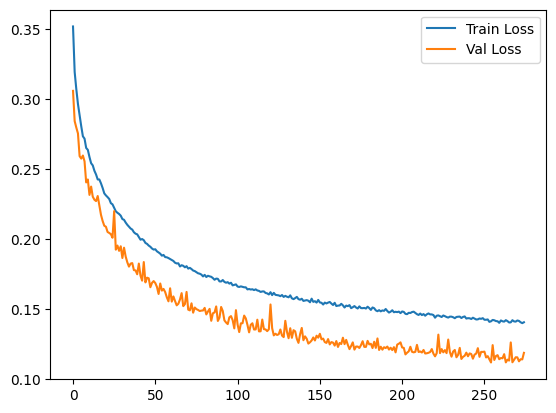

Saved vector PDF: history/20251105-175526/loss_plot.pdf


<Figure size 640x480 with 0 Axes>

In [ ]:
# Load data and train the model

if __name__ == "__main__":

    device, device_type = get_device()
    print(f"Using device: {device_type}")
    
    model = ModifiedModel(input_dim=X_embeddings_train.shape[1], num_classes=settings.N_CLASSES).to(device)

    train_model(X_embeddings_train, y_train, model, device)


Processing and caching in : dataset/synthetic_data/gt_synthetic_mix_1.npz


Loading gt: 100%|██████████| 3/3 [00:00<00:00, 39.01it/s]

Number of instances of class Aircraft: 1 
 Number of instances of class No aircraft: 2 
 Total number of instances: 3
output_array shape: (294, 2)
 1/10 [==>...........................] - ETA: 0s

10/10 [==============================] - 0s 27ms/step
input_embedding shape: (294, 1024)


Saving y to cache: 100%|██████████| 294/294 [00:00<00:00, 16337.33it/s]


...

Number of instances of class Aircraft: 1 
 Number of instances of class No aircraft: 2 
 Total number of instances: 3
output_array shape: (294, 2)


10/10 [==============================] - 0s 33ms/step
input_embedding shape: (294, 1024)


Saving y to cache: 100%|██████████| 294/294 [00:00<00:00, 17296.34it/s]

y_tensor shape: torch.Size([294, 2])
Epoch 1/300 | Train Loss: 50.0398 | Val Loss: 37.8920
Epoch 2/300 | Train Loss: 34.1009 | Val Loss: 26.7862
Epoch 3/300 | Train Loss: 24.3814 | Val Loss: 18.4757
Epoch 4/300 | Train Loss: 15.5565 | Val Loss: 12.4369
Epoch 5/300 | Train Loss: 12.8745 | Val Loss: 8.8693


Epoch 6/300 | Train Loss: 8.4547 | Val Loss: 6.6412
Epoch 7/300 | Train Loss: 6.5785 | Val Loss: 5.3082
Epoch 8/300 | Train Loss: 4.9426 | Val Loss: 4.3274
Epoch 9/300 | Train Loss: 4.2515 | Val Loss: 3.5710
Epoch 10/300 | Train Loss: 3.3882 | Val Loss: 2.9645
Epoch 11/300 | Train Loss: 3.1250 | Val Loss: 2.4911
Epoch 12/300 | Train Loss: 2.3286 | Val Loss: 2.1417
Epoch 13/300 | Train Loss: 2.4716 | Val Loss: 1.8533
Epoch 14/300 | Train Loss: 2.1886 | Val Loss: 1.6659
Epoch 15/300 | Train Loss: 1.8709 | Val Loss: 1.5108
Epoch 16/300 | Train Loss: 1.6607 | Val Loss: 1.3829
Epoch 17/300 | Train Loss: 1.5877 | Val Loss: 1.2691
Epoch 18/300 | Train Loss: 1.6860 | Val Loss: 1.1956
Epoch 19/300 | Train Loss: 1.4712 | Val Loss: 1.1192
Epoch 20/300 | Train Loss: 1.4571 | Val Loss: 1.0662
Epoch 21/300 | Train Loss: 1.3998 | Val Loss: 1.0262
Epoch 22/300 | Train Loss: 1.3441 | Val Loss: 0.9875
Epoch 23/300 | Train Loss: 1.2238 | Val Loss: 0.9515
Epoch 24/300 | Train Loss: 1.0583 | Val Loss: 0.92

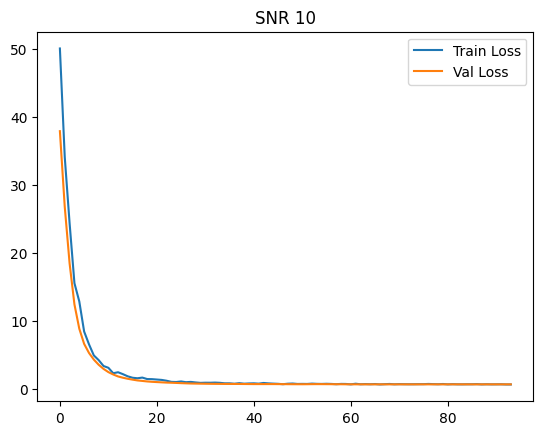

y_tensor shape: torch.Size([294, 2])
Epoch 1/300 | Train Loss: 0.7182 | Val Loss: 0.7128
Epoch 2/300 | Train Loss: 0.6970 | Val Loss: 0.7077
Epoch 3/300 | Train Loss: 0.7065 | Val Loss: 0.7025
Epoch 4/300 | Train Loss: 0.6799 | Val Loss: 0.6981
Epoch 5/300 | Train Loss: 0.6902 | Val Loss: 0.6947
Epoch 6/300 | Train Loss: 0.6812 | Val Loss: 0.6873
Epoch 7/300 | Train Loss: 0.6805 | Val Loss: 0.6843
Epoch 8/300 | Train Loss: 0.6801 | Val Loss: 0.6827
Epoch 9/300 | Train Loss: 0.7007 | Val Loss: 0.6841
Epoch 10/300 | Train Loss: 0.6747 | Val Loss: 0.6835
Epoch 11/300 | Train Loss: 0.6896 | Val Loss: 0.6856
Epoch 12/300 | Train Loss: 0.6839 | Val Loss: 0.6871
Epoch 13/300 | Train Loss: 0.6705 | Val Loss: 0.6867
Epoch 14/300 | Train Loss: 0.6842 | Val Loss: 0.6876
Epoch 15/300 | Train Loss: 0.6711 | Val Loss: 0.6874
Epoch 16/300 | Train Loss: 0.6963 | Val Loss: 0.6859
Epoch 17/300 | Train Loss: 0.6817 | Val Loss: 0.6844
Epoch 18/300 | Train Loss: 0.6777 | Val Loss: 0.6849
Epoch 19/300 | Tra

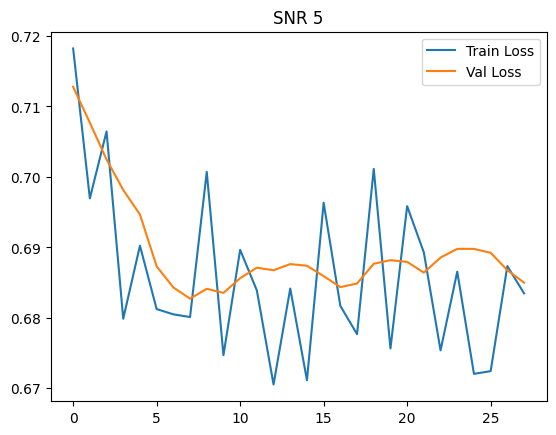

y_tensor shape: torch.Size([294, 2])
Epoch 1/300 | Train Loss: 0.7054 | Val Loss: 0.6613
Epoch 2/300 | Train Loss: 0.6720 | Val Loss: 0.6379
Epoch 3/300 | Train Loss: 0.6663 | Val Loss: 0.6389
Epoch 4/300 | Train Loss: 0.6629 | Val Loss: 0.6392
Epoch 5/300 | Train Loss: 0.6715 | Val Loss: 0.6405
Epoch 6/300 | Train Loss: 0.6761 | Val Loss: 0.6413
Epoch 7/300 | Train Loss: 0.6698 | Val Loss: 0.6422
Epoch 8/300 | Train Loss: 0.6638 | Val Loss: 0.6422
Epoch 9/300 | Train Loss: 0.6762 | Val Loss: 0.6410
Epoch 10/300 | Train Loss: 0.6637 | Val Loss: 0.6406
Epoch 11/300 | Train Loss: 0.6596 | Val Loss: 0.6402
Epoch 12/300 | Train Loss: 0.6671 | Val Loss: 0.6405
Epoch 13/300 | Train Loss: 0.6639 | Val Loss: 0.6407
Epoch 14/300 | Train Loss: 0.6601 | Val Loss: 0.6410
Epoch 15/300 | Train Loss: 0.6566 | Val Loss: 0.6410
Epoch 16/300 | Train Loss: 0.6612 | Val Loss: 0.6408
Epoch 17/300 | Train Loss: 0.6665 | Val Loss: 0.6401
Epoch 18/300 | Train Loss: 0.6641 | Val Loss: 0.6402
Epoch 19/300 | Tra

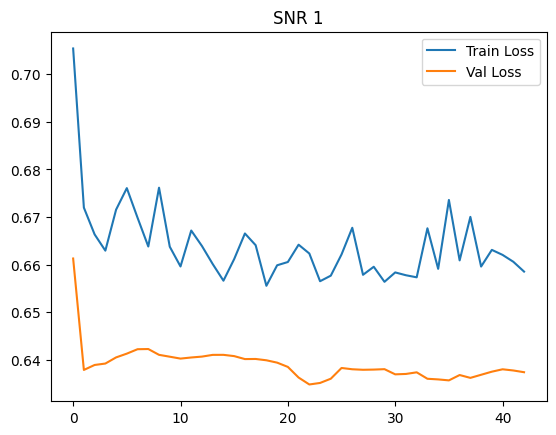

y_tensor shape: torch.Size([294, 2])
Epoch 1/300 | Train Loss: 0.6596 | Val Loss: 0.6712
Epoch 2/300 | Train Loss: 0.6624 | Val Loss: 0.6678
Epoch 3/300 | Train Loss: 0.6579 | Val Loss: 0.6659
Epoch 4/300 | Train Loss: 0.6580 | Val Loss: 0.6662
Epoch 5/300 | Train Loss: 0.6617 | Val Loss: 0.6674
Epoch 6/300 | Train Loss: 0.6495 | Val Loss: 0.6674
Epoch 7/300 | Train Loss: 0.6557 | Val Loss: 0.6678
Epoch 8/300 | Train Loss: 0.6534 | Val Loss: 0.6669
Epoch 9/300 | Train Loss: 0.6524 | Val Loss: 0.6671
Epoch 10/300 | Train Loss: 0.6543 | Val Loss: 0.6683
Epoch 11/300 | Train Loss: 0.6555 | Val Loss: 0.6662
Epoch 12/300 | Train Loss: 0.6555 | Val Loss: 0.6656
Epoch 13/300 | Train Loss: 0.6571 | Val Loss: 0.6649
Epoch 14/300 | Train Loss: 0.6565 | Val Loss: 0.6648
Epoch 15/300 | Train Loss: 0.6579 | Val Loss: 0.6665
Epoch 16/300 | Train Loss: 0.6563 | Val Loss: 0.6677
Epoch 17/300 | Train Loss: 0.6488 | Val Loss: 0.6680
Epoch 18/300 | Train Loss: 0.6559 | Val Loss: 0.6672
Epoch 19/300 | Tra

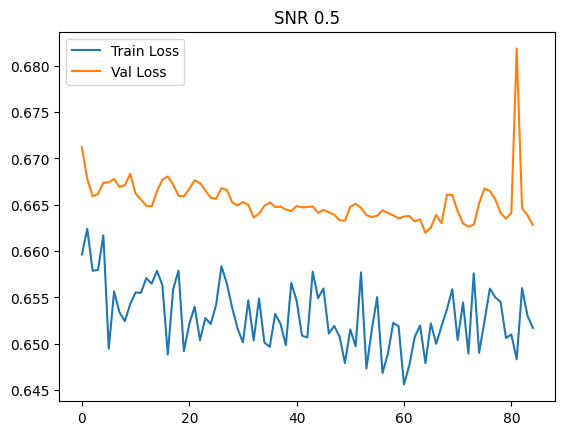

y_tensor shape: torch.Size([294, 2])
Epoch 1/300 | Train Loss: 0.7060 | Val Loss: 0.7320
Epoch 2/300 | Train Loss: 0.7124 | Val Loss: 0.7046
Epoch 3/300 | Train Loss: 0.7004 | Val Loss: 0.6796
Epoch 4/300 | Train Loss: 0.6816 | Val Loss: 0.6712
Epoch 5/300 | Train Loss: 0.6636 | Val Loss: 0.6628
Epoch 6/300 | Train Loss: 0.6696 | Val Loss: 0.6580
Epoch 7/300 | Train Loss: 0.6629 | Val Loss: 0.6543
Epoch 8/300 | Train Loss: 0.6649 | Val Loss: 0.6507
Epoch 9/300 | Train Loss: 0.6571 | Val Loss: 0.6494
Epoch 10/300 | Train Loss: 0.6632 | Val Loss: 0.6477
Epoch 11/300 | Train Loss: 0.6563 | Val Loss: 0.6455
Epoch 12/300 | Train Loss: 0.6671 | Val Loss: 0.6438
Epoch 13/300 | Train Loss: 0.6531 | Val Loss: 0.6430
Epoch 14/300 | Train Loss: 0.6588 | Val Loss: 0.6415
Epoch 15/300 | Train Loss: 0.6552 | Val Loss: 0.6409
Epoch 16/300 | Train Loss: 0.6546 | Val Loss: 0.6405
Epoch 17/300 | Train Loss: 0.6583 | Val Loss: 0.6408
Epoch 18/300 | Train Loss: 0.6591 | Val Loss: 0.6404
Epoch 19/300 | Tra

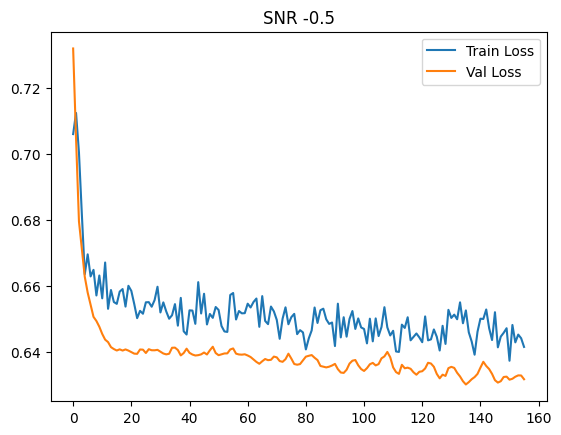

In [31]:
# Load model for further training

path = "history/20251031-174755/modified_model.pt"  
device, _ = get_device()
synthetic_data_folder = "dataset/synthetic_data"

model = torch.load(path, map_location=device, weights_only=False)
snr = [10, 5, 1, 0.5, -0.5] # UPDATE FOR WHEN UPLOADING NEW MIXTURES (Values found in last run of synthetic_data_generations.ipynb)
X_embeddings_mix_1, y_mix_1 = get_data_from_dict(settings.data_pair_mix_1, base_model, force_reload=True)
X_embeddings_mix_2, y_mix_2 = get_data_from_dict(settings.data_pair_mix_2, base_model, force_reload=True)
X_embeddings_mix_3, y_mix_3 = get_data_from_dict(settings.data_pair_mix_3, base_model, force_reload=True)
X_embeddings_mix_4, y_mix_4 = get_data_from_dict(settings.data_pair_mix_4, base_model, force_reload=True)
X_embeddings_mix_5, y_mix_5 = get_data_from_dict(settings.data_pair_mix_5, base_model, force_reload=True)

train_model(X_embeddings_mix_1, y_mix_1, model, device, title= f'SNR {snr[0]}', save=False)
train_model(X_embeddings_mix_2, y_mix_2, model, device, title= f'SNR {snr[1]}', save=False)
train_model(X_embeddings_mix_3, y_mix_3, model, device, title= f'SNR {snr[2]}', save=False)
train_model(X_embeddings_mix_4, y_mix_4, model, device, title= f'SNR {snr[3]}', save=False)
train_model(X_embeddings_mix_5, y_mix_5, model, device, title= f'SNR {snr[4]}', save=False)

In [6]:
# Test and evaluate the model

model.eval()
X_test_tensor = torch.tensor(X_embeddings_test, dtype=torch.float32).to(device)
with torch.no_grad():
    y_pred_test = model(X_test_tensor).cpu().numpy()
y_pred_test = postprocess_output(y_pred_test)  # If needed

X_env_tensor = torch.tensor(X_embeddings_env, dtype=torch.float32).to(device)
with torch.no_grad():
    y_pred_env = model(X_env_tensor).cpu().numpy()
y_pred_env = postprocess_output(y_pred_env)

event_metrics = EventBasedMetrics(event_label_list=settings.CLASS_NAMES, t_collar=params.PATCH_WINDOW_SECONDS)
segment_metrics = SegmentBasedMetrics(event_label_list=settings.CLASS_NAMES, time_resolution=params.PATCH_WINDOW_SECONDS)

predicted_event_list_test = predictions_to_event_list(y_pred_test)
reference_event_list_test = predictions_to_event_list(y_test)
predicted_event_list_env = predictions_to_event_list(y_pred_env)
reference_event_list_env = predictions_to_event_list(y_env)
print("Data processed for evaluation...")
print("Predicted event list test length:", len(predicted_event_list_test))
print("Reference event list test length:", len(reference_event_list_test))
print("Predicted event list env length:", len(predicted_event_list_env))
print("Reference event list env length:", len(reference_event_list_env))

event_metrics.evaluate(predicted_event_list_test, reference_event_list_test)
segment_metrics.evaluate(predicted_event_list_test, reference_event_list_test)

save_sed_metric('Event-based-dataset', event_metrics.results(), timestr)
save_sed_metric('Segment-based-dataset', segment_metrics.results(), timestr)
print_metrics(event_metrics.results(), "Event-based (Test set)")
print_metrics(segment_metrics.results(), "Segment-based (Test set)")

event_metrics.evaluate(predicted_event_list_env, reference_event_list_env)
segment_metrics.evaluate(predicted_event_list_env, reference_event_list_env)

save_sed_metric('Event-based-env-dataset', event_metrics.results(), timestr)
save_sed_metric('Segment-based-env-dataset', segment_metrics.results(), timestr)
print_metrics(event_metrics.results(), "Event-based (Environment set)")
print_metrics(segment_metrics.results(), "Segment-based (Environment set)")

Data processed for evaluation...
Predicted event list test length: 29769
Reference event list test length: 32488
Predicted event list env length: 63923
Reference event list env length: 76002


NameError: name 'timestr' is not defined

In [ ]:
# Load metrics if desired

event_metric = load_sed_metric(f'history/251104-162942/Event-based-env-dataset.pk1')
segment_metric = load_sed_metric(f'history/251104-162942/Segment-based-env-dataset.pk1')

print_metrics(event_metrics.results(), "Event-based (Env set)")
print_metrics(segment_metrics.results(), "Segment-based (Env set)")


FileNotFoundError: [Errno 2] No such file or directory: 'history/251104-162942/Event-based-env-dataset.pk1'

In [ ]:
# Old script for training, made into fucntion train_model()

""" # Prepare PyTorch datasets and loaders
    X_train_tensor = torch.tensor(X_embeddings_train, dtype=torch.float32).to(device)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
    print("y_train_tensor shape:", y_train_tensor.shape)
    train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

    # Validation split
    val_split = getattr(settings, "VAL_SIZE", 0.2)
    num_val = int(len(X_train_tensor) * val_split)
    indices = np.arange(len(X_train_tensor.cpu()))
    np.random.shuffle(indices)
    val_indices = indices[:num_val]
    train_indices = indices[num_val:]
    X_val_tensor = X_train_tensor[val_indices]
    y_val_tensor = y_train_tensor[val_indices]
    val_dataset = torch.utils.data.TensorDataset(X_val_tensor, y_val_tensor)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False)

    #criterion = nn.BCELoss()
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    num_epochs = 300
    patience = 20
    best_loss = float('inf')
    epochs_no_improve = 0
    best_state = None
    train_losses, val_losses = [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for inputs, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
        epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item() * inputs.size(0)
        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)
        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_loss:.4f} | Val Loss: {val_loss:.4f}")

        # Early stopping
        if val_loss < best_loss:
            best_loss = val_loss
            best_state = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print("Early stopping triggered.")
                break

    model.load_state_dict(best_state)

    # SAVE MODEL 
    timestr = time.strftime("%Y%m%d-%H%M%S")
    os.makedirs('history', exist_ok=True)
    os.makedirs(f'history/{timestr}', exist_ok=True)
    torch.save(model, f'history/{timestr}/modified_model.pt')

    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.legend()
    plt.show()
    pdf_path = f'history/{timestr}/loss_plot.pdf'
    plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
    print(f'Saved vector PDF: {pdf_path}') """